First 5 rows of dataset:
   area  bedrooms  bathrooms  floors location  parking   price
0   850         2          1       1   Suburb        1  120000
1  1200         3          2       1     City        1  200000
2  1500         3          2       2     City        2  280000
3  1800         4          3       2     City        2  350000
4   950         2          1       1   Suburb        1  140000

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   area       30 non-null     int64 
 1   bedrooms   30 non-null     int64 
 2   bathrooms  30 non-null     int64 
 3   floors     30 non-null     int64 
 4   location   30 non-null     object
 5   parking    30 non-null     int64 
 6   price      30 non-null     int64 
dtypes: int64(6), object(1)
memory usage: 1.8+ KB
None

Statistical Summary:
              area   bedrooms  bathrooms     

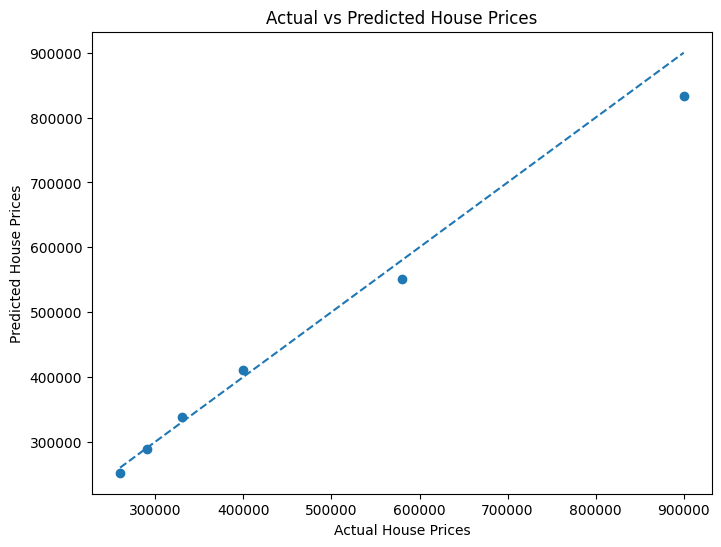

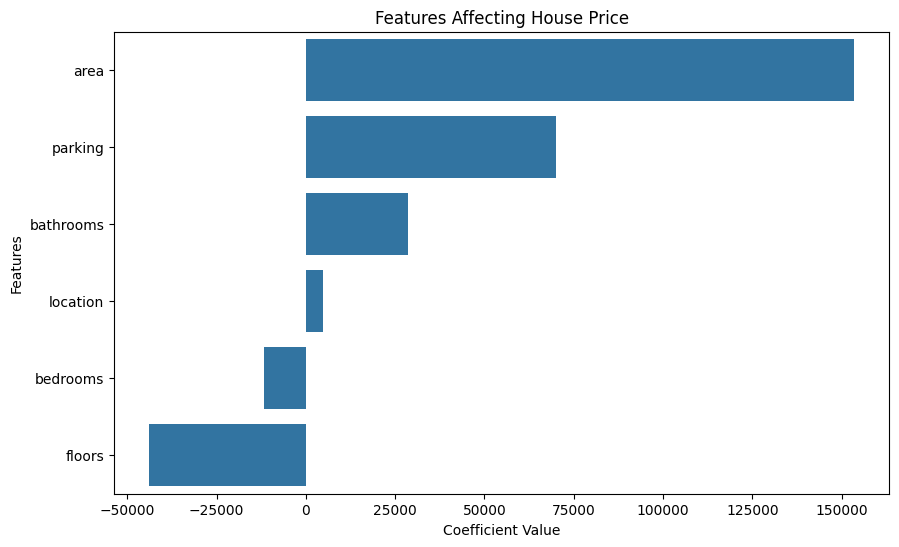

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
df = pd.read_csv("house_price.csv")
print("First 5 rows of dataset:")
print(df.head())
print("\nDataset Information:")
print(df.info())
print("\nStatistical Summary:")
print(df.describe())
print("\nMissing Values:")
print(df.isnull().sum())
df.dropna(inplace=True)
print("\nDuplicate Records:", df.duplicated().sum())
df.drop_duplicates(inplace=True)
label_encoder = LabelEncoder()
for column in df.select_dtypes(include="object").columns:
    df[column] = label_encoder.fit_transform(df[column])
y = df["price"]
X = df.drop("price", axis=1)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("\nModel Performance:")
print("Mean Absolute Error (MAE):", round(mae, 2))
print("Root Mean Squared Error (RMSE):", round(rmse, 2))
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual House Prices")
plt.ylabel("Predicted House Prices")
plt.title("Actual vs Predicted House Prices")
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)
importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

importance = importance.sort_values(
    by="Coefficient",
    ascending=False
)
print("\nFeature Importance:")
print(importance)
plt.figure(figsize=(10, 6))
sns.barplot(
    x="Coefficient",
    y="Feature",
    data=importance
)
plt.title("Features Affecting House Price")
plt.xlabel("Coefficient Value")
plt.ylabel("Features")
plt.show()
